Fragment Length and Normalizing Part

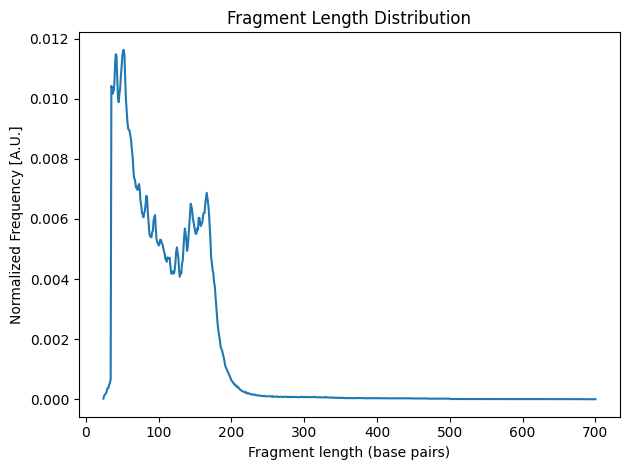

In [7]:
import gzip
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'query.bed.gz'
lengths = []

with gzip.open(file_path, 'rt') as f:
    try:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            cols = line.strip().split('\t')
            start, end = int(cols[1]), int(cols[2])
            lengths.append(end - start)
    except EOFError:
        # We reached at the end of the gzip stream; stop reading further.
        pass

# Create a DataFrame of fragment lengths
df = pd.DataFrame({'length': lengths})

# Count frequencies
freq = df['length'].value_counts().sort_index()
normalized_freq = freq / freq.sum()

# Plot
plt.figure()
plt.plot(normalized_freq.index, normalized_freq.values)
plt.xlabel('Fragment length (base pairs)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')
plt.tight_layout()
plt.show()

Rescaling And Plotting the Queries i.e Original , Reference and Rescaled

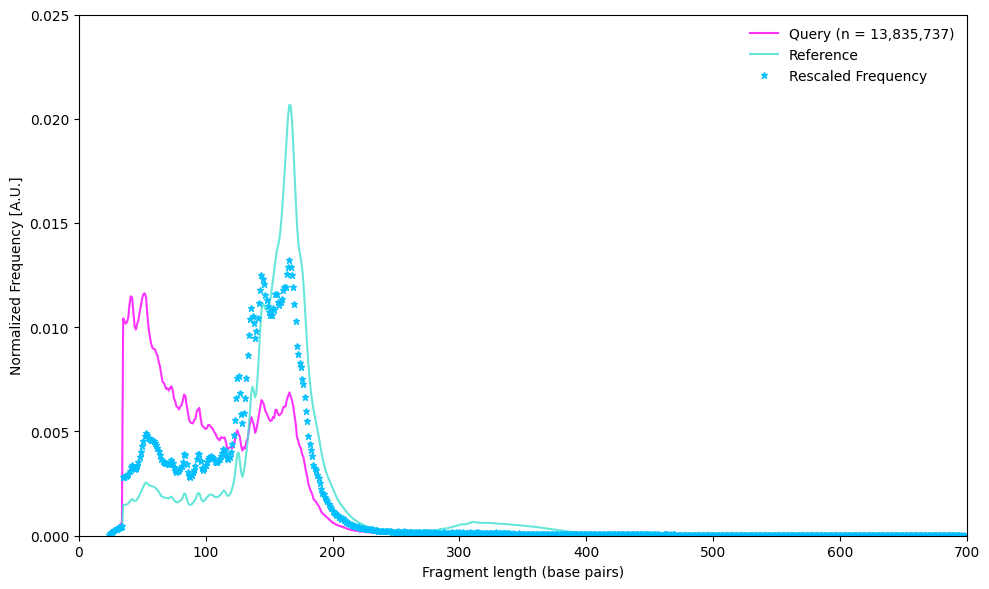

In [ ]:
# I have written the comments for easy understanding 

import gzip
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

# Load the required files
ref = pd.read_csv('reference.hist', sep='\t', header=None, names=['length', 'ref_freq'])
ref = ref.sort_values('length')

file_path = 'query.bed.gz'
lengths = []
with gzip.open(file_path, 'rt') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        cols = line.strip().split('\t')
        start, end = int(cols[1]), int(cols[2])
        lengths.append(end - start)

q_df = pd.DataFrame({'length': lengths})
q_total = len(q_df)

query_freq = q_df['length'].value_counts().sort_index()
query_freq_df = query_freq.reset_index()
query_freq_df.columns = ['length', 'count']

# Merging the reference and query
merged = pd.merge(ref, query_freq_df, on='length', how='inner')

# Normalizing
merged['ref_prob']   = merged['ref_freq']   / merged['ref_freq'].sum()
merged['query_prob'] = merged['count']      / merged['count'].sum()
merged['resample_prob'] = (merged['ref_prob'] / merged['query_prob']).clip(upper=1.0)

# Resampling Begins
resampled_lenth = []
for _, row in merged.iterrows():
    length = int(row['length'])
    prob   = row['resample_prob']
    subset = q_df[q_df['length'] == length]
    sampled = subset.sample(frac=prob, random_state=42)
    resampled_lenth.extend(sampled['length'])

resampled_df   = pd.DataFrame({'length': resampled_lenth})
resampled_total = len(resampled_df)

ref_freq_norm       = ref.set_index('length')['ref_freq']    / ref['ref_freq'].sum()
query_freq_norm     = q_df['length'].value_counts(normalize=True).sort_index()
resampled_freq_norm = resampled_df['length'].value_counts(normalize=True).sort_index()




# Plotting begins
plt.figure(figsize=(10, 6))

plt.plot(
    query_freq_norm.index,
    query_freq_norm.values,
    label=f"Query (n = {q_total:,})",
    color='magenta',
    linewidth=1.5,
    alpha=0.8
)

plt.plot(
    ref_freq_norm.index,
    ref_freq_norm.values,
    label="Reference",
    color='turquoise',
    linewidth=1.5,
    alpha=0.8
)

plt.plot(
    resampled_freq_norm.index,
    resampled_freq_norm.values,
    '*',
    label=f"Rescaled Frequency",
    color='deepskyblue',
    markersize=5,
    alpha=0.9
)

plt.xlim(0, 700)
plt.ylim(0, 0.025)

plt.xlabel('Fragment length (base pairs)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.xticks(np.arange(0, 701, 100))
plt.yticks(np.arange(0, 0.026, 0.005))
plt.grid(False)

plt.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()